### Image classifier for the SVHN dataset

In [49]:
#importing libraries

import tensorflow as tf
from scipy.io import loadmat
import matplotlib.pyplot as plt
import numpy as np
import random

from tensorflow.keras import Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, BatchNormalization, Dropout, GlobalAveragePooling2D
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

In [2]:
train = loadmat("D:\\Tensorflow_Works\\15-Image_Classifier_For_SVHN_Dataset\\data\\train_32x32.mat")
test = loadmat("D:\\Tensorflow_Works\\15-Image_Classifier_For_SVHN_Dataset\\data\\test_32x32.mat")

In [3]:
train.keys()

dict_keys(['__header__', '__version__', '__globals__', 'X', 'y'])

In [4]:
train['X'].shape

(32, 32, 3, 73257)

In [5]:
#inspecting dataset

x_train = np.transpose(train['X'], (3,0,1,2))
y_train = np.transpose(train['y'], (0,1))

x_test = np.transpose(test['X'], (3,0,1,2))
y_test = np.transpose(test['y'], (0,1))

print(x_train.shape)
print(y_train.shape)
print(f"\n{x_test.shape}")
print(y_test.shape)



(73257, 32, 32, 3)
(73257, 1)

(26032, 32, 32, 3)
(26032, 1)


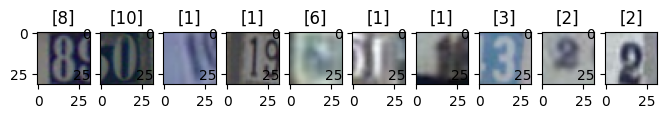

In [6]:
#some sample images

num_samples = x_train.shape[0]
n_index = np.random.choice(num_samples, 10)
plt.subplots(1,10, figsize=(8,12))
for n, i in enumerate(n_index):
    plt.subplot(1, 10, n+1)
    plt.imshow(x_train[i])
    plt.title(y_train[i])


In [34]:
#function to convert images to monochrome

def monochrome(x):
    avg_color = np.mean(x, axis=-1,)
    return avg_color[..., np.newaxis]

x_train_grey = monochrome(x_train)
x_test_grey = monochrome(x_test)

In [35]:
#rescaling values between 0 -1

x_train_grey = x_train_grey/255.
x_test_grey = x_test_grey/255.

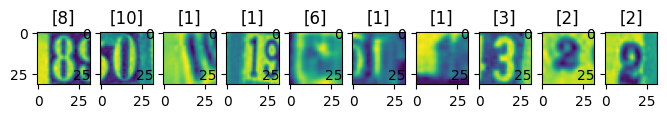

In [36]:
#some sample grey images

plt.subplots(1,10, figsize=(8,12))
for n, i in enumerate(n_index):
    plt.subplot(1, 10, n+1)
    plt.imshow(x_train_grey[i])
    plt.title(y_train[i])

In [37]:
x_train_grey.shape

(73257, 32, 32, 1)

##### MLP Netural Network Classifier

In [42]:
#model building
model = Sequential([
    Input(shape=x_train_grey[0].shape),
    Flatten(),
    Dense(units=64, activation="relu"),
    Dense(units=64, activation="relu"),
    Dense(units=32, activation="relu"),
    Dense(units=32, activation="softmax"),
    Dense(units=11, activation="softmax")
])

#model compiling
model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy", 
              metrics=['accuracy'])

model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_9 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 11)             │           363 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 73,259 (286.17 KB)

 Trainable params: 73,259 (286.17 KB)

 Non-trainable params: 0 (0.00 B)

#####

In [43]:
#model training

history = model.fit(x_train_grey, y_train, epochs=30, validation_data=(x_test_grey,y_test), callbacks= [ModelCheckpoint("checkpoint_epoch/{epoch:00d}_my_checkpoint.weights.h5", save_weights_only=True, save_freq="epoch")])

Epoch 1/30
2290/2290 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.1887 - loss: 2.2608 - val_accuracy: 0.1959 - val_loss: 2.2299
Epoch 2/30
2290/2290 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.1892 - loss: 2.2399 - val_accuracy: 0.1959 - val_loss: 2.2258
Epoch 3/30
2290/2290 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.1892 - loss: 2.2376 - val_accuracy: 0.1959 - val_loss: 2.2246
Epoch 4/30
2290/2290 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.1892 - loss: 2.2370 - val_accuracy: 0.1959 - val_loss: 2.2244
Epoch 5/30
2290/2290 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.1892 - loss: 2.2369 - val_accuracy: 0.1959 - val_loss: 2.2240
Epoch 6/30
2290/2290 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.1892 - loss: 2.2367 - val_accuracy: 0.1959 - val_loss: 2.2239
Epoch 7/30
2290/2290 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.1895 - loss: 2.2356 - val_accuracy: 0.2005 - val_loss: 2.2074
Epoch 8/30
2290/2290 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.2038 - loss: 2.1968 - 

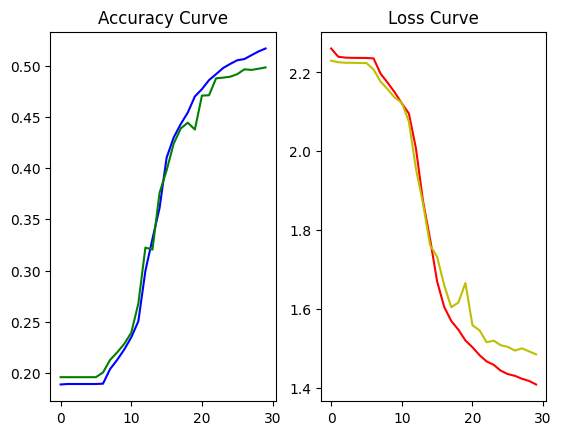

In [46]:
def visual_plot(history):

    accuracy = history.history['accuracy']
    loss = history.history['loss']
    val_accuracy = history.history['val_accuracy']
    val_loss = history.history['val_loss']

    plt.subplot(1,2,1)
    plt.plot(accuracy, 'b', label="training accuracy")
    plt.plot(val_accuracy, 'g', label="validation accuracy")
    plt.title("Accuracy Curve")

    plt.subplot(1,2,2)
    plt.plot(loss, 'r', label="training loss")
    plt.plot(val_loss, 'y', label="validation loss")
    plt.title("Loss Curve")

visual_plot(history)

In [47]:
#model evaluation

model.evaluate(x_test_grey, y_test)

814/814 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4983 - loss: 1.4844


[1.4844410419464111, 0.49830976128578186]

#### CNN Neural Network Classifier

In [50]:
cnn_model = Sequential([
    Input(shape=x_train_grey[0].shape),
    Conv2D(filters=64, kernel_size=3, padding="same", activation="relu" ),
    MaxPooling2D(pool_size=2),
    BatchNormalization(momentum=0.99),
    Conv2D(filters=64, kernel_size=3, padding="same", activation="relu" ),
    MaxPooling2D(pool_size=2),
    BatchNormalization(momentum=0.99),
    Conv2D(filters=32, kernel_size=3, padding="same", activation="relu" ),
    MaxPooling2D(pool_size=2),
    BatchNormalization(momentum=0.99),
    GlobalAveragePooling2D(),
    Dense(units=128, activation="relu"),
    Dropout(rate=0.3),
    Dense(units=32, activation="relu"),
    Dropout(rate=0.2),
    Dense(units=11, activation="softmax")


])

In [51]:
#ccn model compiling

cnn_model.compile(optimizer="adam",
                  loss="sparse_categorical_crossentropy", 
                  metrics=['accuracy'])

In [52]:
cnn_model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 32)       │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 4, 4, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 32)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 11)             │           363 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65,387 (255.42 KB)

 Trainable params: 65,067 (254.17 KB)

 Non-trainable params: 320 (1.25 KB)

In [ ]:
#model training
cnn_history = cnn_model.fit(x_train_grey, y_train, epochs=30, validation_data=(x_test_grey,y_test), callbacks= [ModelCheckpoint("cnn_checkpoint_epoch/{epoch:00d}_my_checkpoint.weights.h5", save_weights_only=True, save_freq="epoch")])

Epoch 1/30
2290/2290 ━━━━━━━━━━━━━━━━━━━━ 25s 10ms/step - accuracy: 0.5225 - loss: 1.3829 - val_accuracy: 0.7732 - val_loss: 0.7103
Epoch 2/30
2290/2290 ━━━━━━━━━━━━━━━━━━━━ 23s 10ms/step - accuracy: 0.7988 - loss: 0.6572 - val_accuracy: 0.8398 - val_loss: 0.5291
Epoch 3/30
2290/2290 ━━━━━━━━━━━━━━━━━━━━ 23s 10ms/step - accuracy: 0.8442 - loss: 0.5260 - val_accuracy: 0.8653 - val_loss: 0.4508
Epoch 4/30
2290/2290 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8589 - loss: 0.4727

In [ ]:
def visual_plot(cnn_history):

    accuracy = cnn_history.history['accuracy']
    loss = cnn_history.history['loss']
    val_accuracy = cnn_history.history['val_accuracy']
    val_loss = cnn_history.history['val_loss']

    plt.subplot(1,2,1)
    plt.plot(accuracy, 'b', label="training accuracy")
    plt.plot(val_accuracy, 'g', label="validation accuracy")
    plt.title("Accuracy Curve")

    plt.subplot(1,2,2)
    plt.plot(loss, 'r', label="training loss")
    plt.plot(val_loss, 'y', label="validation loss")
    plt.title("Loss Curve")

visual_plot(cnn_history)